# Experiment 3 — Lead-aware 1D CNN + Grad-CAM (revised)

Exploratory deep-learning approach, complementary to the binned classical models of
Experiment 1. A small convolutional network reads the raw `(12, 200)` QRS and encodes its
spatio-temporal structure (temporal locality within a lead; lead fusion only at the end),
following Saglietto et al. (2024). Grad-CAM provides a `lead × time` interpretability map.

**What changed vs. the first version (read this):**

1. **Augmentation bug fixed.** The old `Lambda(lambda t: augment_ecg(t, training=True))` applied
   noise *at inference too*, so every `predict` saw a different noisy signal. We now use native
   Keras augmentation layers (`GaussianNoise`, `RandomScaling`) that are automatically inactive
   at inference.
2. **Double-metric cross-validation.** Like Experiment 1, every fold reports both *global* and
   *Teknon-only* validation metrics, because the final test is 100% Teknon while the pool is
   mostly simulated.
3. **Stabilised training.** Lower learning rate, longer patience, early-stopping on `val_loss`
   (less noisy than `val_auc`), and an optional multi-seed average per fold to avoid the
   single-fold collapse seen before.
4. **Test touched once**, at the end, after CV.


## 0. Imports & config

In [1]:
import os
# If running locally, adapt:
# os.chdir(r"c:\Users\jaime\Downloads\corrected_split_pool\corrected_split_pool")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, roc_curve)

import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers, callbacks
print("TensorFlow:", tf.__version__, "| GPU:", len(tf.config.list_physical_devices('GPU')) > 0)

RANDOM_STATE = 42
N_FOLDS = 5
N_BINS = 10
N_SEEDS = 1          # set to 3 for multi-seed averaging per fold (slower, more stable)

LEAD_NAMES = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]
CLASS_NAMES = ["LVOT", "RVOT"]

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
SKF = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def find_file(filename):
    for p in (Path(".") / filename, Path("..") / filename):
        if p.exists():
            return str(p)
    raise FileNotFoundError(f"Could not find {filename}.")

print("Config loaded.")

I0000 00:00:1780399944.627857    6824 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780399944.980692    6824 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780399946.354801    6824 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0 | GPU: True
Config loaded.


W0000 00:00:1780399947.269230    6824 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## 1. Load data

In [2]:
X_train_pool = np.load(find_file("X_train_pool_binary_corrected_clean.npy")).astype(np.float32)
y_train_pool = np.load(find_file("y_train_pool_binary_corrected_clean.npy")).astype(int)
X_test = np.load(find_file("X_teknon_final_test_binary_corrected_clean.npy")).astype(np.float32)
y_test = np.load(find_file("y_teknon_final_test_binary_corrected_clean.npy")).astype(int)
info_train = pd.read_csv(find_file("info_train_pool_binary_corrected_clean.csv"))
info_test  = pd.read_csv(find_file("info_teknon_final_test_binary_corrected_clean.csv"))

IS_TEKNON = (info_train["dataset"].astype(str).values == "Teknon")

# Keras Conv2D wants (N, H, W, C): leads = height, time = width, 1 channel.
def to_cnn(X):
    return X[..., np.newaxis]

X_pool_cnn = to_cnn(X_train_pool)
X_test_cnn = to_cnn(X_test)

print("X_pool_cnn:", X_pool_cnn.shape, "| X_test_cnn:", X_test_cnn.shape)
print("Pool class balance:", dict(zip(*np.unique(y_train_pool, return_counts=True))))
print("Teknon rows in pool:", int(IS_TEKNON.sum()))

X_pool_cnn: (3009, 12, 200, 1) | X_test_cnn: (36, 12, 200, 1)
Pool class balance: {np.int64(0): np.int64(1613), np.int64(1): np.int64(1396)}
Teknon rows in pool: 137


## 2. Augmentation — native Keras layers (the bug fix)

A custom `RandomScaling` layer multiplies the whole sample by a random factor; `GaussianNoise`
adds noise. Both inherit Keras' `training` flag, so they are **active during `fit` and inactive
during `predict`/`evaluate`** automatically — no more inference-time corruption.

In [3]:
class RandomScaling(layers.Layer):
    """Multiply each sample by a random amplitude factor (train only)."""
    def __init__(self, low=0.85, high=1.15, **kw):
        super().__init__(**kw)
        self.low, self.high = low, high
    def call(self, x, training=None):
        if not training:
            return x
        amp = tf.random.uniform([tf.shape(x)[0], 1, 1, 1], self.low, self.high)
        return x * amp
    def get_config(self):
        c = super().get_config(); c.update(low=self.low, high=self.high); return c

# Quick check that scaling is identity at inference
_test_layer = RandomScaling()
_x = tf.constant(X_pool_cnn[:2])
print("Identity at inference:", np.allclose(_test_layer(_x, training=False).numpy(), _x.numpy()))
print("Changes at train     :", not np.allclose(_test_layer(_x, training=True).numpy(), _x.numpy()))

W0000 00:00:1780400158.292703    6824 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1780400158.458830    6824 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5233 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


Identity at inference: True
Changes at train     : True


## 3. CNN architecture (Saglietto-style, lead-aware)

* Four `Conv(1×k)–BN–LeakyReLU–Pool` blocks: filters slide only along time, leads never mix.
* A `1×1` conv mixes channels per `(lead, time)` cell — **Grad-CAM target** (`last_conv_act`).
* `GlobalAveragePooling2D` fuses leads, then a small dense head with dropout.
* ~15k parameters, deliberately small for a ~3k-sample pool.

In [4]:
def build_cnn(input_shape=(12, 200, 1), l2_reg=1e-4, dropout=0.3):
    reg = regularizers.l2(l2_reg)
    inp = layers.Input(shape=input_shape, name="qrs_input")

    # Native augmentation — automatically inactive at inference (the bug fix)
    x = layers.GaussianNoise(0.03)(inp)
    x = RandomScaling(0.85, 1.15)(x)

    for n_f, k in [(16, 7), (32, 5), (32, 3), (64, 3)]:
        x = layers.Conv2D(n_f, (1, k), padding="same", kernel_regularizer=reg)(x)
        x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU(alpha=0.1)(x)
        x = layers.MaxPooling2D((1, 2))(x)

    x = layers.Conv2D(32, (1, 1), padding="same", kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1, name="last_conv_act")(x)   # Grad-CAM target

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(16, activation="relu", kernel_regularizer=reg)(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(1, activation="sigmoid", name="prob_RVOT")(x)
    return Model(inp, out, name="LeadAwareCNN")

tf.keras.backend.clear_session()
build_cnn().summary(line_length=80)

Model: "LeadAwareCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ qrs_input (InputLayer)            │ (None, 12, 200, 1)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ gaussian_noise (GaussianNoise)    │ (None, 12, 200, 1)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ random_scaling (RandomScaling)    │ (None, 12, 200, 1)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d (Conv2D)                   │ (None, 12, 200, 16)      │           128 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization               │ (None, 12, 200, 16)      │            64 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)           │ (None, 12, 200, 16)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)      │ (None, 12, 100, 16)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)                 │ (None, 12, 100, 32)      │         2,592 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_1             │ (None, 12, 100, 32)      │           128 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)         │ (None, 12, 100, 32)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)    │ (None, 12, 50, 32)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)                 │ (None, 12, 50, 32)       │         3,104 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_2             │ (None, 12, 50, 32)       │           128 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)         │ (None, 12, 50, 32)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)    │ (None, 12, 25, 32)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)                 │ (None, 12, 25, 64)       │         6,208 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_3             │ (None, 12, 25, 64)       │           256 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)         │ (None, 12, 25, 64)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)    │ (None, 12, 12, 64)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)                 │ (None, 12, 12, 32)       │         2,080 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_4             │ (None, 12, 12, 32)       │           128 │
│ (BatchNormalization)              │                          │               │
├──────────────────────────────

 Total params: 15,361 (60.00 KB)

 Trainable params: 15,009 (58.63 KB)

 Non-trainable params: 352 (1.38 KB)

## 4. Training helper (stabilised)

Changes vs. the old version: `lr = 5e-4` (was 1e-3), `patience = 12` (was 8), early-stopping on
`val_loss` (was the noisier `val_auc`). `class_weight` handles the LVOT/RVOT imbalance.
Optional multi-seed averaging (`N_SEEDS`) makes a fold robust to a single bad initialisation.

In [5]:
def train_one(X_tr, y_tr, X_va, y_va, seed=RANDOM_STATE, max_epochs=80, batch_size=64, verbose=0):
    tf.keras.backend.clear_session()
    tf.random.set_seed(seed)
    model = build_cnn()
    model.compile(optimizer=tf.keras.optimizers.Adam(5e-4),
                  loss="binary_crossentropy",
                  metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])
    n0, n1 = (y_tr == 0).sum(), (y_tr == 1).sum()
    cw = {0: (n0 + n1) / (2 * n0), 1: (n0 + n1) / (2 * n1)}
    es = callbacks.EarlyStopping(monitor="val_loss", mode="min",
                                 patience=12, restore_best_weights=True)
    rl = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5)
    hist = model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                     epochs=max_epochs, batch_size=batch_size, class_weight=cw,
                     callbacks=[es, rl], verbose=verbose)
    return model, hist

def predict_proba_cnn(models, X):
    """Average P(RVOT) over one or several (multi-seed) models."""
    preds = np.mean([m.predict(X, verbose=0).ravel() for m in models], axis=0)
    return preds

print("Training helpers ready.")

Training helpers ready.


## 5. Double-metric cross-validation

Identical philosophy to Experiment 1: every fold reports global and Teknon-only validation
metrics. Within each CV fold we carve a small inner split for early stopping. If `N_SEEDS > 1`,
each fold trains several models and averages their probabilities, which is what kills the
single-fold collapse.

In [6]:
def metrics_block(y_true, y_pred, y_score):
    out = {"accuracy": accuracy_score(y_true, y_pred),
           "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
           "macro_f1": f1_score(y_true, y_pred, average="macro")}
    out["roc_auc"] = roc_auc_score(y_true, y_score) if len(np.unique(y_true)) == 2 else np.nan
    return out

cv_rows = []
t0 = time.time()
for fold, (tr_idx, va_idx) in enumerate(SKF.split(X_pool_cnn, y_train_pool)):
    X_trva, y_trva = X_pool_cnn[tr_idx], y_train_pool[tr_idx]
    X_va,   y_va   = X_pool_cnn[va_idx], y_train_pool[va_idx]

    # inner split (≈15%) for early stopping
    inner = StratifiedKFold(7, shuffle=True, random_state=RANDOM_STATE + fold)
    in_tr, in_es = next(iter(inner.split(X_trva, y_trva)))
    X_in_tr, y_in_tr = X_trva[in_tr], y_trva[in_tr]
    X_in_es, y_in_es = X_trva[in_es], y_trva[in_es]

    models = []
    for s in range(N_SEEDS):
        m, h = train_one(X_in_tr, y_in_tr, X_in_es, y_in_es, seed=RANDOM_STATE + 10 * s)
        models.append(m)

    score = predict_proba_cnn(models, X_va)
    pred = (score >= 0.5).astype(int)

    g = metrics_block(y_va, pred, score)
    tek = IS_TEKNON[va_idx]
    tk = metrics_block(y_va[tek], pred[tek], score[tek]) if tek.sum() > 0 \
         else {k: np.nan for k in g}
    cv_rows.append({"fold": fold, "n_val_teknon": int(tek.sum()),
                    **{f"g_{k}": v for k, v in g.items()},
                    **{f"t_{k}": v for k, v in tk.items()}})
    print(f"Fold {fold+1}/{N_FOLDS}: global bal_acc={g['balanced_accuracy']:.3f} | "
          f"Teknon bal_acc={tk['balanced_accuracy']:.3f}", flush=True)

cv_df = pd.DataFrame(cv_rows)
cv_df.to_csv("exp3_cnn_cv_results.csv", index=False)
print(f"\nCV done in {time.time()-t0:.0f}s")
cv_df.round(3)

I0000 00:00:1780400185.736247    7652 service.cc:153] XLA service 0x792bdc050310 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780400185.736279    7652 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060 Laptop GPU, Compute Capability 12.0a (Driver: 13.3.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1780400185.811327    7652 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
W0000 00:00:1780400185.924858    7652 random_ops.cc:62] Warning: Using tf.random.uniform with XLA compilation will ignore seeds; consider using tf.random.stateless_uniform instead if reproducible behavior is desired. LeadAwareCNN_1/random_scaling_1/random_uniform/RandomUniform
I0000 00:00:1780400186.173470    7652 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1780400186.278067    7652 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6049

Fold 1/5: global bal_acc=0.964 | Teknon bal_acc=0.792


I0000 00:00:1780400224.589775    7651 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_35655__.91
I0000 00:00:1780400228.187672    7650 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_35655__.91


Fold 2/5: global bal_acc=0.963 | Teknon bal_acc=0.656


I0000 00:00:1780400252.810986    7651 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_69923__.91
I0000 00:00:1780400256.437189    7649 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_69923__.91


...

I0000 00:00:1780400278.948870    7652 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_99730__.91
I0000 00:00:1780400282.454547    7650 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_99730__.91


Fold 4/5: global bal_acc=0.958 | Teknon bal_acc=0.708


I0000 00:00:1780400303.177178    7652 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_127451__.91
I0000 00:00:1780400306.708695    7650 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_127451__.91


Fold 5/5: global bal_acc=0.936 | Teknon bal_acc=0.620

CV done in 150s


,fold,n_val_teknon,g_accuracy,g_balanced_accuracy,g_macro_f1,g_roc_auc,t_accuracy,t_balanced_accuracy,t_macro_f1,t_roc_auc
0,0,21,0.963,0.964,0.963,0.993,0.810,0.792,0.798,0.880
1,1,24,0.962,0.963,0.962,0.987,0.708,0.656,0.661,0.742
2,2,27,0.960,0.961,0.960,0.992,0.741,0.736,0.735,0.794
3,3,36,0.958,0.958,0.958,0.983,0.667,0.708,0.662,0.741
4,4,29,0.933,0.936,0.933,0.982,0.655,0.620,0.618,0.725


In [7]:
print("=== CV summary (mean ± std) ===")
for c in ["g_balanced_accuracy", "t_balanced_accuracy", "g_roc_auc", "t_roc_auc"]:
    print(f"  {c:22s}: {cv_df[c].mean():.3f} ± {cv_df[c].std():.3f}")

=== CV summary (mean ± std) ===
  g_balanced_accuracy   : 0.956 ± 0.012
  t_balanced_accuracy   : 0.703 ± 0.067
  g_roc_auc             : 0.988 ± 0.005
  t_roc_auc             : 0.777 ± 0.063


## 6. Final model — evaluate ONCE on the Teknon test

Retrain on the whole pool (10% held out for early stopping), average over `N_SEEDS`, evaluate
once on the 36-patient Teknon test. Includes a bootstrap CI for the small n.

In [8]:
rng = np.random.RandomState(RANDOM_STATE)
idx = np.arange(len(X_pool_cnn)); rng.shuffle(idx)
n_es = int(0.10 * len(idx))
es_i, tr_i = idx[:n_es], idx[n_es:]

final_models = []
for s in range(N_SEEDS):
    m, h = train_one(X_pool_cnn[tr_i], y_train_pool[tr_i],
                     X_pool_cnn[es_i], y_train_pool[es_i],
                     seed=RANDOM_STATE + 10 * s, max_epochs=100)
    final_models.append(m)

y_score_cnn = predict_proba_cnn(final_models, X_test_cnn)
y_pred_cnn  = (y_score_cnn >= 0.5).astype(int)

final = metrics_block(y_test, y_pred_cnn, y_score_cnn)
final["weighted_f1"] = f1_score(y_test, y_pred_cnn, average="weighted")
pd.DataFrame([final]).to_csv("exp3_cnn_test_results.csv", index=False)
print("=== FINAL Teknon test (CNN) ===")
for k, v in final.items():
    print(f"  {k:20s}: {v:.3f}")
print()
print(classification_report(y_test, y_pred_cnn, target_names=CLASS_NAMES))

# bootstrap CI on balanced accuracy
boot = []
for _ in range(2000):
    bi = rng.randint(0, len(y_test), len(y_test))
    if len(np.unique(y_test[bi])) == 2:
        boot.append(balanced_accuracy_score(y_test[bi], y_pred_cnn[bi]))
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"\nBalanced accuracy: {final['balanced_accuracy']:.3f} (95% CI {lo:.3f}–{hi:.3f})")

I0000 00:00:1780400344.519751    7651 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_161194__.91
I0000 00:00:1780400348.341041    7650 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_161194__.91


=== FINAL Teknon test (CNN) ===
  accuracy            : 0.722
  balanced_accuracy   : 0.722
  macro_f1            : 0.721
  roc_auc             : 0.778
  weighted_f1         : 0.721

              precision    recall  f1-score   support

        LVOT       0.70      0.78      0.74        18
        RVOT       0.75      0.67      0.71        18

    accuracy                           0.72        36
   macro avg       0.72      0.72      0.72        36
weighted avg       0.73      0.72      0.72        36


Balanced accuracy: 0.722 (95% CI 0.562–0.863)


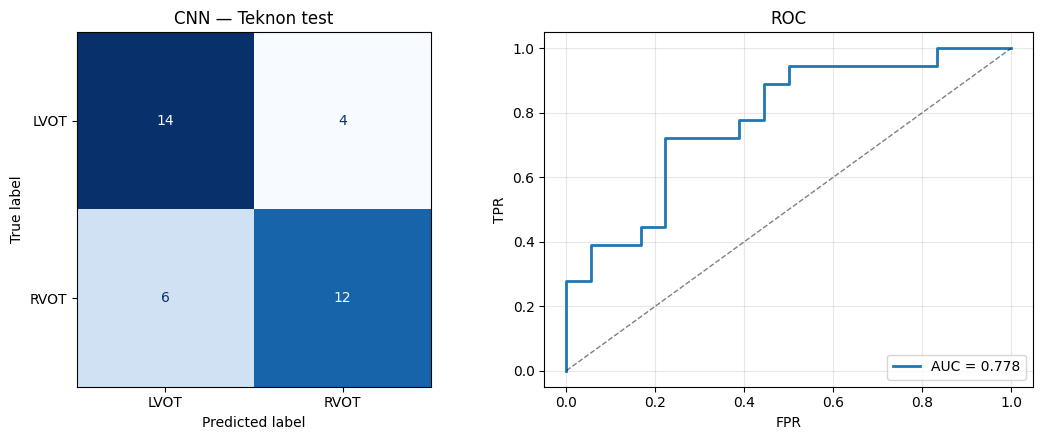

In [9]:
cm = confusion_matrix(y_test, y_pred_cnn)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title("CNN — Teknon test")
fpr, tpr, _ = roc_curve(y_test, y_score_cnn)
axes[1].plot(fpr, tpr, lw=2, label=f"AUC = {final['roc_auc']:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].set_title("ROC")
axes[1].legend(loc="lower right"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig("fig_exp3_confusion_roc.png", dpi=150, bbox_inches="tight"); plt.show()

## 7. Grad-CAM

Gradient of the RVOT score w.r.t. the last conv layer, pooled over channels → a `lead × time`
heatmap. `reduce_retracing=True` avoids the retracing warning from the old version.

In [10]:
@tf.function(reduce_retracing=True)
def _gradcam_step(grad_model, x, target_class):
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(x, training=False)
        score = preds[:, 0] if target_class == 1 else (1.0 - preds[:, 0])
    return conv_out, tape.gradient(score, conv_out)

def compute_gradcam(model, X, target_class=1, layer_name="last_conv_act"):
    grad_model = tf.keras.Model(model.input,
                                [model.get_layer(layer_name).output, model.output])
    conv_out, grads = _gradcam_step(grad_model, tf.constant(X), target_class)
    weights = tf.reduce_mean(grads, axis=(1, 2))
    cam = tf.einsum("blwc,bc->blw", conv_out, weights)
    cam = tf.nn.relu(cam).numpy()
    m = cam.max(axis=(1, 2), keepdims=True)
    return np.divide(cam, m, out=np.zeros_like(cam), where=m > 0)

# Average Grad-CAM over correctly-classified TEKNON patients only (more honest than the pool,
# which is mostly simulated). We use the test patients here as the cleanest real example set.
correct = (y_pred_cnn == y_test)
cam_l = compute_gradcam(final_models[0], X_test_cnn[correct & (y_test == 0)], 0).mean(0)
cam_r = compute_gradcam(final_models[0], X_test_cnn[correct & (y_test == 1)], 1).mean(0)
print("Grad-CAM heatmaps:", cam_l.shape, cam_r.shape)

Grad-CAM heatmaps: (12, 12) (12, 12)


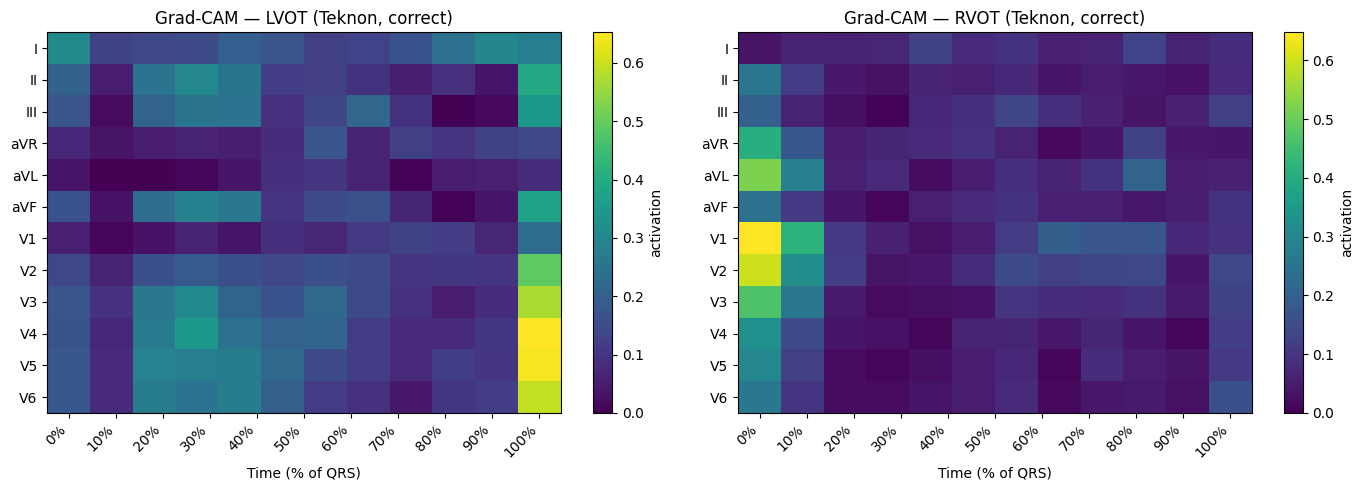

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
Tp = cam_l.shape[1]
for ax, cam, name in zip(axes, [cam_l, cam_r], ["LVOT", "RVOT"]):
    im = ax.imshow(cam, aspect="auto", cmap="viridis", vmin=0)
    ax.set_yticks(range(12)); ax.set_yticklabels(LEAD_NAMES)
    ax.set_xticks(np.linspace(0, Tp - 1, 11))
    ax.set_xticklabels([f"{p}%" for p in range(0, 101, 10)], rotation=45, ha="right")
    ax.set_xlabel("Time (% of QRS)"); ax.set_title(f"Grad-CAM — {name} (Teknon, correct)")
    fig.colorbar(im, ax=ax, label="activation")
plt.tight_layout(); plt.savefig("fig_exp3_gradcam.png", dpi=150, bbox_inches="tight"); plt.show()

## 8. Convergence figure — CNN Grad-CAM vs. binned RandomForest importance

Trains a quick RF on the 120 binned features and shows its `lead × bin` importance next to the
class-averaged Grad-CAM. If both light up V2–V4 around the R/S transition, that matches
Bocanegra's SHAP finding — three independent analyses converging.

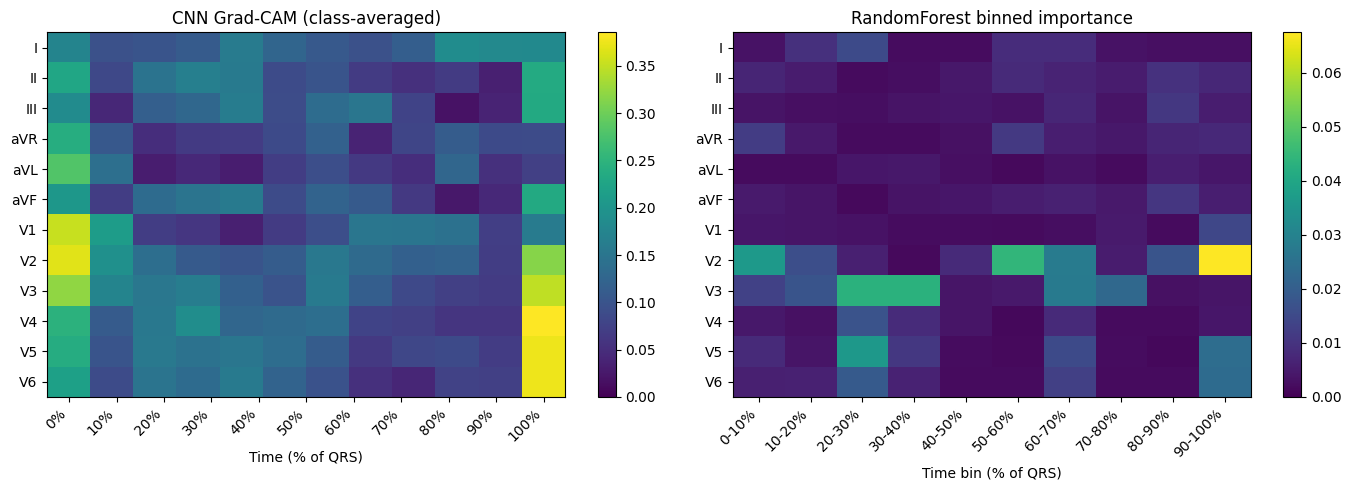

In [12]:
def binned(X, n_bins=N_BINS):
    edges = np.linspace(0, X.shape[2], n_bins + 1, dtype=int)
    out = np.zeros((X.shape[0], 12 * n_bins), np.float32)
    for li in range(12):
        for bi in range(n_bins):
            out[:, li * n_bins + bi] = X[:, li, edges[bi]:edges[bi+1]].mean(1)
    return out

rf = RandomForestClassifier(n_estimators=500, class_weight="balanced",
                            random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(binned(X_train_pool), y_train_pool)
rf_imp = rf.feature_importances_.reshape(12, N_BINS)

cam_combined = 0.5 * (cam_l + cam_r)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im0 = axes[0].imshow(cam_combined, aspect="auto", cmap="viridis", vmin=0)
axes[0].set_yticks(range(12)); axes[0].set_yticklabels(LEAD_NAMES)
axes[0].set_xticks(np.linspace(0, cam_combined.shape[1]-1, 11))
axes[0].set_xticklabels([f"{p}%" for p in range(0, 101, 10)], rotation=45, ha="right")
axes[0].set_title("CNN Grad-CAM (class-averaged)"); axes[0].set_xlabel("Time (% of QRS)")
fig.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(rf_imp, aspect="auto", cmap="viridis", vmin=0)
axes[1].set_yticks(range(12)); axes[1].set_yticklabels(LEAD_NAMES)
axes[1].set_xticks(range(N_BINS))
axes[1].set_xticklabels([f"{i*10}-{(i+1)*10}%" for i in range(N_BINS)], rotation=45, ha="right")
axes[1].set_title("RandomForest binned importance"); axes[1].set_xlabel("Time bin (% of QRS)")
fig.colorbar(im1, ax=axes[1])
plt.tight_layout(); plt.savefig("fig_exp3_cnn_vs_rf.png", dpi=150, bbox_inches="tight"); plt.show()

## 9. Summary

* **Fixes:** inference-safe augmentation, double-metric CV (global + Teknon), stabilised
  training (lr 5e-4, patience 12, `val_loss`), optional multi-seed averaging.
* **Reading:** compare the CNN's Teknon-validation balanced accuracy against Experiment 1's
  classical models. The gap between global and Teknon metrics is the same domain-shift story.
* **Interpretability:** Grad-CAM (now averaged over real Teknon cases) vs. RF importance vs.
  Bocanegra's SHAP — convergence on V2–V4 / R/S transition.

**Artifacts:** `exp3_cnn_cv_results.csv`, `exp3_cnn_test_results.csv`,
`fig_exp3_confusion_roc.png`, `fig_exp3_gradcam.png`, `fig_exp3_cnn_vs_rf.png`.

> To make the CNN robust against the single-fold collapse seen previously, set `N_SEEDS = 3` at
> the top. It triples training time but averages out unlucky initialisations.
